# Performance Analytics

This notebook computes advanced mutual fund performance metrics using daily NAV data.

### Objectives

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

PROJECT_ROOT = Path("..")

DATA = PROJECT_ROOT / "data" / "processed"

OUTPUT = PROJECT_ROOT / "outputs"

print("Setup Complete")

Setup Complete


In [2]:
fund_master = pd.read_csv(DATA/"01_fund_master_clean.csv")

nav = pd.read_csv(DATA/"02_nav_history_clean.csv")

performance = pd.read_csv(DATA/"07_scheme_performance_clean.csv")

benchmark = pd.read_csv(DATA/"10_benchmark_indices_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("Data Loaded")

Data Loaded


In [3]:
# Sort first
nav = nav.sort_values(
    ["amfi_code","date"]
)

# Daily Return
nav["daily_return"] = (
    nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

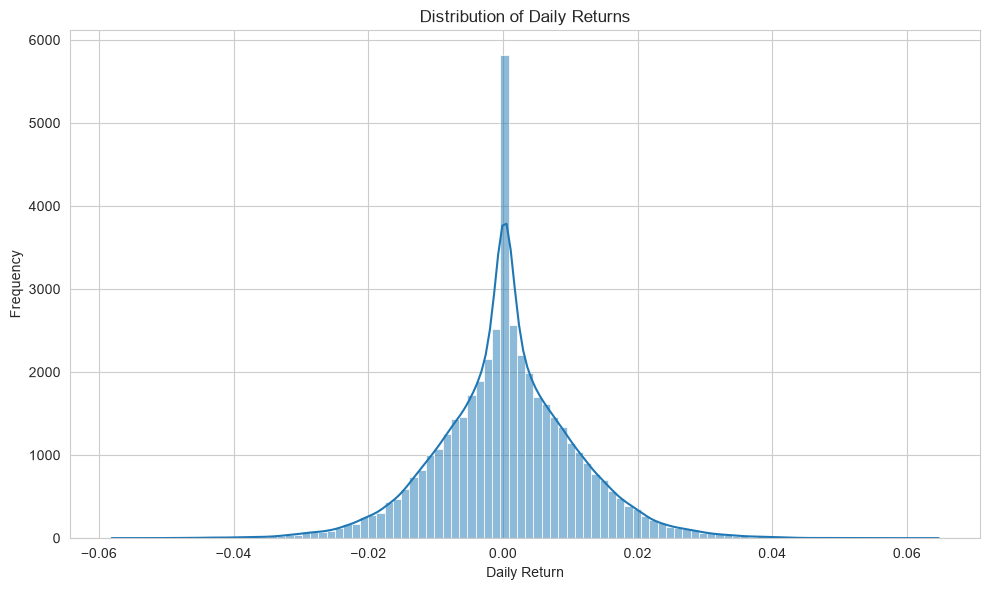

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [6]:
nav["daily_return"].isna().sum()

np.int64(40)

In [7]:
(Path("../outputs/csv")).mkdir(parents=True, exist_ok=True)

nav.to_csv(
    "../outputs/csv/nav_with_returns.csv",
    index=False
)

print("Daily returns saved.")

Daily returns saved.


## Daily Return Validation

Daily returns were calculated for all mutual fund schemes using percentage change in NAV. The return distribution is centered near zero with both positive and negative observations, which is consistent with expected day-to-day market movements. The first observation for each scheme has a missing value because there is no previous trading day for comparison.

# CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualized growth of a mutual fund over a specified investment horizon.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1/n) - 1

In [8]:
# ==========================================
# CAGR Function
# ==========================================

def calculate_cagr(df, years):
    """
    Calculate CAGR for a given investment horizon.
    """

    results = []

    latest_date = df["date"].max()

    start_date = latest_date - pd.DateOffset(years=years)

    for code, group in df.groupby("amfi_code"):

        group = group.sort_values("date")

        period = group[group["date"] >= start_date]

        if len(period) < 2:
            continue

        start_nav = period.iloc[0]["nav"]
        end_nav = period.iloc[-1]["nav"]

        cagr = (end_nav / start_nav) ** (1 / years) - 1

        results.append({
            "amfi_code": code,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(results)

In [9]:
cagr_1 = calculate_cagr(nav, 1)

cagr_3 = calculate_cagr(nav, 3)

cagr_5 = calculate_cagr(nav, 5)

In [10]:
cagr = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
)

cagr = cagr.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [11]:
cols = ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]

cagr[cols] = cagr[cols] * 100

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-2.224271,1.292649,2.316843,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,3.704969,3.916390,3.912653,HDFC Short Term Debt Fund - Regular - Growth
2,100033,53.232396,32.442459,26.074068,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,47.924120,28.967695,20.442730,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-23.986032,-4.152381,6.953336,ABSL Small Cap Fund - Regular - Growth


In [12]:
top = cagr.sort_values(
    "CAGR_5Y",
    ascending=False
)

top.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
25,120505,29.604659,31.777537,28.376762,ICICI Pru Midcap Fund - Regular - Growth
21,119598,82.776059,26.669922,28.033224,SBI Small Cap Fund - Regular Plan - Growth
39,149324,65.138719,27.000427,27.917430,DSP Small Cap Fund - Regular - Growth
36,148569,39.751761,29.178902,27.629860,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,20.360678,34.000916,26.799277,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,26.657082,29.582770,26.742494,Kotak Flexicap Fund - Regular - Growth
2,100033,53.232396,32.442459,26.074068,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,21.481222,26.869991,25.611807,DSP Midcap Fund - Regular - Growth
16,119094,22.261065,35.111802,24.445309,Axis Midcap Fund - Regular - Growth
19,119551,60.437341,30.456524,22.384873,SBI Bluechip Fund - Regular Plan - Growth


In [13]:
(Path("../outputs/csv")).mkdir(
    parents=True,
    exist_ok=True
)

cagr.to_csv(
    "../outputs/csv/cagr_table.csv",
    index=False
)

# Maximum Drawdown

Maximum Drawdown measures the largest percentage decline from a historical peak in NAV.

Formula:

Drawdown = NAV / Running Maximum − 1

In [14]:
def max_drawdown(group):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] /
        group["running_max"]
    ) - 1

    worst = group.loc[
        group["drawdown"].idxmin()
    ]

    peak_idx = group.loc[:worst.name, "nav"].idxmax()

    peak_date = group.loc[
        peak_idx,
        "date"
    ]

    return pd.Series({
        "max_drawdown": worst["drawdown"],
        "peak_date": peak_date,
        "trough_date": worst["date"]
    })

In [15]:
drawdown = (
    nav
    .groupby("amfi_code")
    .apply(max_drawdown)
    .reset_index()
)

In [16]:
drawdown = drawdown.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

drawdown.head()

,amfi_code,max_drawdown,peak_date,trough_date,scheme_name
0,100016,-0.247344,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-05-23,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-03-11,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-04-24,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [17]:
drawdown["max_drawdown"] = (
    drawdown["max_drawdown"] * 100
)

drawdown.head()

,amfi_code,max_drawdown,peak_date,trough_date,scheme_name
0,100016,-24.734441,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-4.308264,2023-05-23,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-16.217209,2022-03-11,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-11.291596,2023-04-24,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-35.446916,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [18]:
drawdown.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown,peak_date,trough_date,scheme_name
22,119599,-52.574221,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-51.677754,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-35.446916,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-31.171900,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-28.706006,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-28.001124,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-24.734441,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-24.003511,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-23.344886,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-21.751396,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth


In [19]:
drawdown.to_csv(
    "../outputs/csv/max_drawdown.csv",
    index=False
)

Funds with higher long-term CAGR demonstrate stronger compounded growth over the investment horizon, making CAGR an effective metric for comparing sustained fund performance.

Maximum Drawdown highlights the downside risk experienced by each fund, showing the largest decline from a previous peak and providing a useful measure of capital preservation.

# Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund by comparing its excess return over the risk-free rate to the volatility of its daily returns.

Formula:

Sharpe = ((Rp − Rf) / σ) × √252

Assumption:
- Risk-Free Rate (Rf) = 6.5% annually
- Trading Days = 252

In [20]:
# Annual Risk-Free Rate
RF = 0.065

# Convert to daily
daily_rf = RF / 252

print(daily_rf)

0.00025793650793650796


In [21]:
def calculate_sharpe(group):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        return np.nan

    excess = returns.mean() - daily_rf

    volatility = returns.std()

    if volatility == 0:
        return np.nan

    sharpe = (excess / volatility) * np.sqrt(252)

    return sharpe

In [22]:
sharpe = (
    nav
    .groupby("amfi_code")
    .apply(calculate_sharpe)
    .reset_index(name="Sharpe_Ratio")
)

In [23]:
sharpe = sharpe.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sharpe.head()

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [24]:
sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [25]:
sharpe.to_csv(
    "../outputs/csv/sharpe_ratio.csv",
    index=False
)

# Sortino Ratio

Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility.

Formula:

Sortino = ((Rp − Rf) / Downside Std) × √252

Only negative daily returns are included in the denominator.

In [26]:
def calculate_sortino(group):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        return np.nan

    downside = returns[returns < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std()

    if downside_std == 0:
        return np.nan

    excess = returns.mean() - daily_rf

    sortino = (
        excess /
        downside_std
    ) * np.sqrt(252)

    return sortino

In [27]:
sortino = (
    nav
    .groupby("amfi_code")
    .apply(calculate_sortino)
    .reset_index(name="Sortino_Ratio")
)

In [28]:
sortino = sortino.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sortino.head()

,amfi_code,Sortino_Ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [29]:
sortino = sortino.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino.head(10)

,amfi_code,Sortino_Ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [30]:
sortino.to_csv(
    "../outputs/csv/sortino_ratio.csv",
    index=False
)

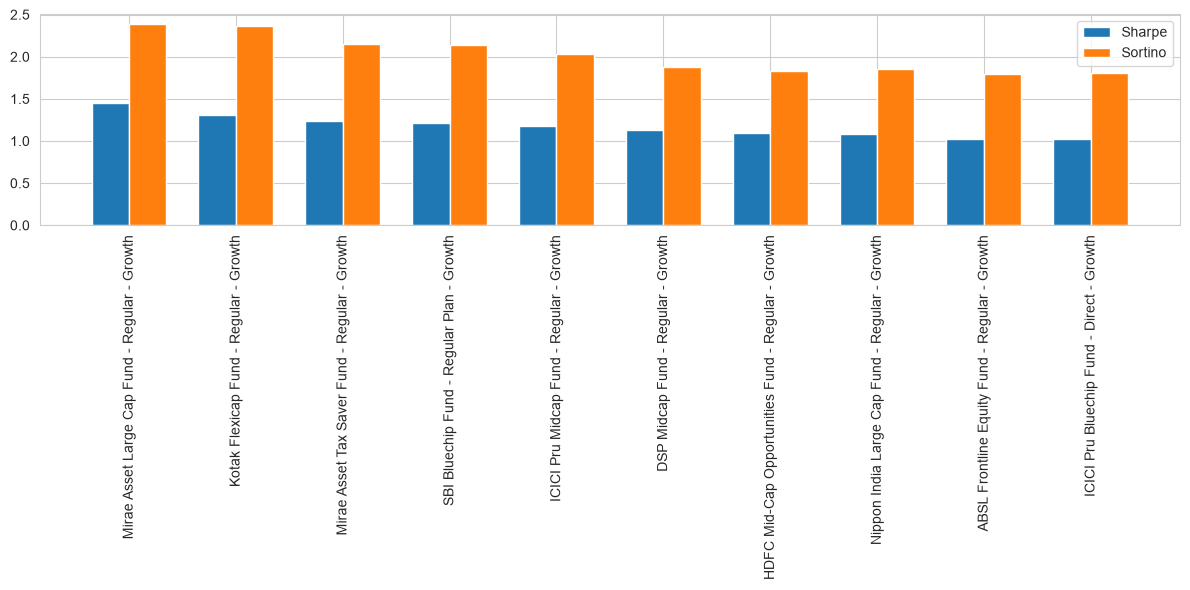

In [31]:
compare = sharpe.merge(
    sortino,
    on=["amfi_code","scheme_name"]
)

top10 = compare.head(10)

plt.figure(figsize=(12,6))

x = np.arange(len(top10))
width = 0.35

plt.bar(
    x - width/2,
    top10["Sharpe_Ratio"],
    width,
    label="Sharpe"
)

plt.bar(
    x + width/2,
    top10["Sortino_Ratio"],
    width,
    label="Sortino"
)

plt.xticks(
    x,
    top10["scheme_name"],
    rotation=90
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sharpe_sortino_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Funds with higher Sharpe Ratios generated stronger risk-adjusted returns by delivering higher excess returns relative to overall volatility.

Sortino Ratios were generally higher than Sharpe Ratios because they penalize only downside volatility, providing a more focused measure of downside risk-adjusted performance.

# Alpha and Beta Analysis

Alpha and Beta are calculated by regressing each fund's daily returns against the benchmark's daily returns.

- Beta = Slope of the regression line
- Alpha = Annualized regression intercept (Intercept × 252)

The Nifty 100 index is used as the benchmark.

In [32]:
# Select Nifty 100 benchmark
nifty100 = benchmark[
    benchmark["index_name"].str.upper() == "NIFTY100"
].copy()

# Calculate benchmark daily returns
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

In [33]:
def calculate_alpha_beta(group):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        return pd.Series({
            "Alpha": np.nan,
            "Beta": np.nan
        })

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = regression.intercept * 252
    beta = regression.slope

    return pd.Series({
        "Alpha": alpha,
        "Beta": beta
    })

In [34]:
alpha_beta = (
    nav
    .groupby("amfi_code")
    .apply(calculate_alpha_beta)
    .reset_index()
)

In [35]:
alpha_beta = alpha_beta.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [36]:
alpha_beta.to_csv(
    "../outputs/csv/alpha_beta.csv",
    index=False
)

# Tracking Error

Tracking Error measures how closely a mutual fund follows its benchmark.

Formula:

Tracking Error = Std(Fund Return − Benchmark Return) × √252

In [37]:
def tracking_error(group):

    merged = group.merge(
        nifty100,
        on="date"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        return np.nan

    diff = (
        merged["daily_return"] -
        merged["benchmark_return"]
    )

    return diff.std() * np.sqrt(252)

In [38]:
tracking = (
    nav
    .groupby("amfi_code")
    .apply(tracking_error)
    .reset_index(name="Tracking_Error")
)

tracking.head()

,amfi_code,Tracking_Error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [39]:
scorecard = (
    cagr[
        ["amfi_code", "CAGR_3Y"]
    ]
    .merge(
        sharpe[
            ["amfi_code", "Sharpe_Ratio"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta[
            ["amfi_code", "Alpha"]
        ],
        on="amfi_code"
    )
    .merge(
        performance[
            ["amfi_code", "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
    .merge(
        drawdown[
            ["amfi_code", "max_drawdown"]
        ],
        on="amfi_code"
    )
    .merge(
        fund_master[
            ["amfi_code", "scheme_name"]
        ],
        on="amfi_code"
    )
)

In [40]:
scorecard["return_rank"] = (
    scorecard["CAGR_3Y"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["Sharpe_Ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["Alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [41]:
scorecard["Fund_Score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_3Y,Sharpe_Ratio,Alpha,expense_ratio_pct,max_drawdown,scheme_name,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund_Score
25,120505,31.777537,1.180101,0.292636,1.36,-18.188514,ICICI Pru Midcap Fund - Regular - Growth,0.900,0.900,0.950,0.6500,0.625,84.5000
16,119094,35.111802,0.998231,0.260767,1.38,-20.960884,Axis Midcap Fund - Regular - Growth,1.000,0.750,0.800,0.6000,0.700,80.7500
2,100033,32.442459,1.093699,0.271954,1.38,-16.217209,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.925,0.850,0.875,0.6000,0.500,80.5000
34,148567,34.000916,1.448291,0.269838,1.46,-11.265729,Mirae Asset Large Cap Fund - Regular - Growth,0.975,1.000,0.850,0.4500,0.200,80.0000
30,120843,29.582770,1.306744,0.273305,1.45,-12.973968,Kotak Flexicap Fund - Regular - Growth,0.850,0.975,0.900,0.4750,0.325,78.2500
24,120504,32.487429,1.026524,0.211948,0.80,-12.588276,ICICI Pru Bluechip Fund - Direct - Growth,0.950,0.775,0.700,0.7250,0.300,75.7500
21,119598,26.669922,0.945308,0.303370,1.43,-28.706006,SBI Small Cap Fund - Regular Plan - Growth,0.725,0.675,1.000,0.5000,0.900,75.1250
39,149324,27.000427,0.949796,0.300579,1.52,-31.171900,DSP Small Cap Fund - Regular - Growth,0.775,0.700,0.975,0.3625,0.925,74.9375
36,148569,29.178902,1.234930,0.282704,1.60,-16.396743,Mirae Asset Tax Saver Fund - Regular - Growth,0.825,0.950,0.925,0.1125,0.525,73.9375
19,119551,30.456524,1.208267,0.232010,1.54,-15.012385,SBI Bluechip Fund - Regular Plan - Growth,0.875,0.925,0.775,0.2625,0.425,73.0625


In [42]:
scorecard.to_csv(
    "../outputs/csv/fund_scorecard.csv",
    index=False
)

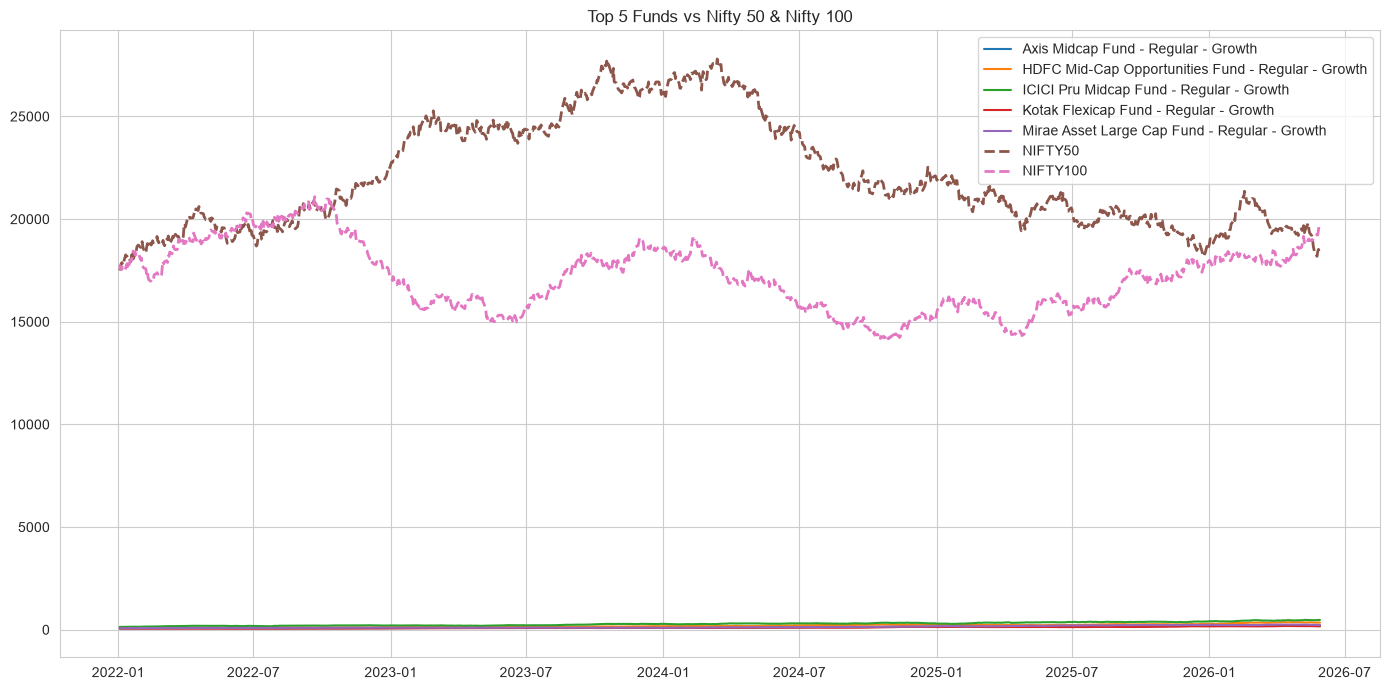

In [43]:
top5 = scorecard.head(5)["amfi_code"]

comparison = nav[
    nav["amfi_code"].isin(top5)
].merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

plt.figure(figsize=(14,7))

for name, grp in comparison.groupby("scheme_name"):
    plt.plot(
        grp["date"],
        grp["nav"],
        label=name
    )

for idx in ["NIFTY50", "NIFTY100"]:
    bench = benchmark[
        benchmark["index_name"].str.upper() == idx
    ]
    plt.plot(
        bench["date"],
        bench["close_value"],
        linestyle="--",
        linewidth=2,
        label=idx
    )

plt.legend()
plt.title("Top 5 Funds vs Nifty 50 & Nifty 100")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/benchmark_comparison.png",
    dpi=300
)

plt.show()